## Set up

In [35]:
from pathlib import Path
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, pearsonr
from IPython.display import display, HTML
import sys
import analysis_utility_funcs as unified_funcs

In [36]:
src_path = Path().resolve() / "../../src"
sys.path.append(src_path)
project_root = src_path.resolve().parent  
sys.path.append(str(project_root))

In [37]:

import src.generic_analysis_utils as generic_analysis_utils

In [38]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



helper code in [`analysis_ntbk_helpers.py`](./analysis_ntbk_helpers.py) 

## Load the Annotated Franken dataset as a dataframe.


### condition descriptions:
- Scenarios have two intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- Within each, 8 causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- 8 Each causal condition contains 10 annotated scenarios, SID index them from 0-9 within each condition
-  Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- The annotator generates multiple outcome events for each scenarios, each event gets its own row. So total row count is 800+.

In [39]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../../annotated_outputs/franken_o1o2/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]

In [40]:
all_FRANKEN_df["evitability"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "evitable" if "_evitable_" in x else "inevitable" if "_inevitable_" in x else "unknown")
all_FRANKEN_df["means_vs_sideeffect"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "means" if "cc_" in x else "sideeffect" if "coc_" in x else "unknown")

#convert + and -'s into 1's and 0's fcor C I and K columns
all_FRANKEN_df["C"] = all_FRANKEN_df["C"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["I"] = all_FRANKEN_df["I"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["K"] = all_FRANKEN_df["K"].apply(lambda x: 1 if x == "+" else 0)

In [41]:
display(HTML(all_FRANKEN_df[0:5].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition,evitability,means_vs_sideeffect
0,0,1: renovate the park.,The park closes temporarily,i,1,1,1,"{'i': '0', 'residents of the community who use or value the park': '-55'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,1,1,1,"{'i': '0', 'residents of the community who use or value the park': '-68'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
2,0,1: renovate the park.,Residents experience inconvenience,i,1,0,1,"{'i': '0', 'residents of the community who use or value the park': '-35'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
3,0,1: renovate the park.,Residents experience disappointment,i,1,0,1,"{'i': '-12', 'residents of the community who use or value the park': '-55'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
4,0,1: renovate the park.,Park facilities are improved,i,1,1,1,"{'i': '12', 'residents of the community who use or value the park': '84'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means


number of rows in all_FRANKEN_df: 754


# Analysis 4 -- Do "severe" scenarios get events with more extreme utility scores than "mild" scenarios?
### Comparing the utility score distributions between mild and severe counterparts of each causal condition (also checking overall)
### **Commonsense hypothesis =** The "severe_harm_very_good" utility distributions SHOULD be more negative (on the harm side) AND more positive (on the good side) overall than the "mild_harm_mild_good" utility distributions.

#### **How do we pick one utility score to represent a scenario?**
##### A scenario has several generated events, and each event has its own utility score per identified entity (agent + any bystanders/patients). Reducing all of that down to one number per scenario is two independent choices:

1. ##### **Which entities count** -- the `UTILITY_PICK_STRATEGY` flag in the next cell:
    - ##### **`simplest`** -- everyone (the agent "i" and every other identified entity)
    - ##### **`i_only`** -- just the agent "i"
    - ##### **`non_i_only`** -- everyone except "i", i.e. all patients/bystanders, undifferentiated

2. ##### **How to reduce the pool to one number** -- `UTILITY_AGG_FUNC` in the next cell. Every value from every entity selected above, across every event of the scenario, is pooled into one flat list first (entities are never treated specially relative to each other or to other events once step 1 has picked which ones count) -- then that pool is reduced with:
    - ##### **`min`** -- most-negative value in the pool ("primary harm" magnitude -- peak severity)
    - ##### **`max`** -- most-positive value in the pool ("primary good" magnitude -- peak severity)
    - ##### **`np.mean`** -- average across everything in the pool (overall/average tone, rather than the single worst/best moment)

##### Change both flags in the next cell.

In [42]:
UTILITY_PICK_STRATEGY = "non_i_only" 

UTILITY_AGG_FUNC = np.mean

In [43]:
def _pooled_utility(utility_dicts, strategy, agg_func):
    """Pools every entity's utility value (selected by `strategy`) across every event in
    `utility_dicts` into one flat list, then reduces that pool to a single number with `agg_func`.
    The one-scenario building block shared by _reduce_to_per_scenario (Analysis 4, many event-rows
    grouped per scenario) and Analysis 5 (already one row per scenario, applied directly).
    """
    if strategy not in ("simplest", "i_only", "non_i_only"):
        raise ValueError(f'Unknown strategy {strategy!r} -- must be "simplest", "i_only", or "non_i_only"')
    keep_key = {"simplest": lambda k: True, "i_only": lambda k: k == "i", "non_i_only": lambda k: k != "i"}[strategy]
    pool = [float(v) for d in utility_dicts for k, v in d.items() if keep_key(k)]
    return agg_func(pool) if pool else float("nan")


def _reduce_to_per_scenario(df, agg_func, strategy=None):
    """Reduces each scenario down to one independent utility observation.

    For every event in a scenario, keeps the utility value of every entity selected by
    UTILITY_PICK_STRATEGY (or `strategy` if passed explicitly), pools all of those values --
    across every entity AND every event of the scenario -- into one flat list, then reduces that
    flat pool to a single number with `agg_func` (e.g. the builtins `min`/`max`, or `np.mean`).
    """
    strategy = strategy if strategy is not None else UTILITY_PICK_STRATEGY
    return df.groupby([df["SID"], df["causal_condition"], df["intensity"]])["utility"].agg(
        lambda utility_dicts: _pooled_utility(utility_dicts, strategy, agg_func)
    )


scenario_vals = _reduce_to_per_scenario(all_FRANKEN_df, UTILITY_AGG_FUNC).dropna()
overall_utility_df = scenario_vals.reset_index(name="utility")
overall_utility_df["intensity"] = overall_utility_df["intensity"].map({"mild_harm_mild_good": "Mild", "severe_harm_very_good": "Severe"})

overall_utility_df.head()

,SID,causal_condition,intensity,utility
0,0,cc_evitable_action_yes_stories,Mild,-25.800000
1,0,cc_evitable_action_yes_stories,Severe,-26.444444
2,0,cc_evitable_prevention_no_stories,Mild,-32.500000
3,0,cc_evitable_prevention_no_stories,Severe,24.535714
4,0,cc_inevitable_action_yes_stories,Mild,-4.600000


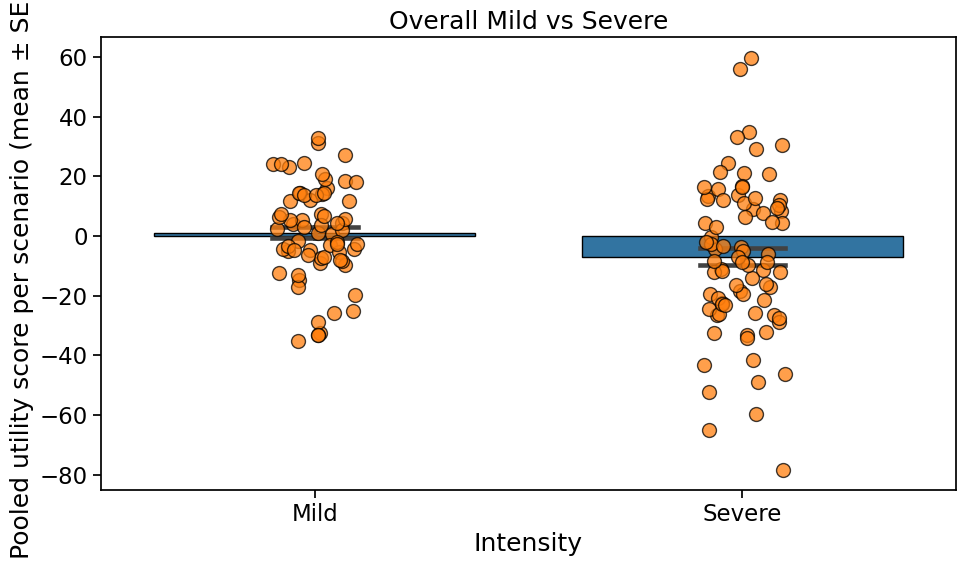

In [44]:
generic_analysis_utils.plot_bar_strip(overall_utility_df, x="intensity", y="utility", ylabel="Pooled utility score per scenario (mean ± SEM)", title="Overall Mild vs Severe")

In [ ]:
print("Harm magnitude (pooled utility, UTILITY_AGG_FUNC applied):")
mild_utilities = overall_utility_df[overall_utility_df["intensity"] == "Mild"]["utility"]
severe_utilities = overall_utility_df[overall_utility_df["intensity"] == "Severe"]["utility"]
t_stat, p_value = ttest_ind(mild_utilities, severe_utilities)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

### **RESULT:**

- ### The utility scores look more negative-shifted in general for severe scenarios in general.

- ### This tell us that the "severe" scenarios' worst scores are more negative than "mild" scenarios' worst scores. (So "severe_harm" is indeed more severe than "mild_harm"). 

- ### Is "_very_good" indeed more good than "_mild_good" though? We don't know that part. We could know if we compared the most positive event utility scores b/w severe and mild scenarios instead (which would be the opposite of a primary harm), but it doesn't really matter as a thing to check. I suspect it is true.

### **RESULT:** Severe utility score distributions are (basically) always statistically significantly more negative than mild counterpart.

# Analysis 5: Are human Exp1 harm/good ratings correlated with annotator utility scores?

### **Explanation of Exp1 human ratings:**

#### Each scenatio recieves a harm rating and a good rating by a human when they are shown separate underspecified versions of the same scenario. 

#### So, when collecting the harm rating, **the human is not shown the full scenaro_text;** instead, they are shown **just the background sentence** (e.g. `"Amara has the opportunity to test a new, lightweight but less protective combat gear in training exercises."`) and either a **good** or a **bad** counterpart of a **target sentence** (e.g. either `"The gear is a bit lighter."` or `"The gear offers marginally less protection against bruises than standard gear."`). 

#### Then they are asked "Rate how good or bad the event in the target sentence is." on a scale of 1-7 where 7 = "Very Good".

#### This experiment stimuli matches up, but is a bit different in nature than, the full scenario text we pass into the annotator, which contains both the good and bad target sentences (`"I, a Soldier, face a moral dilemma. I have the opportunity to test a new, lightweight but less protective combat gear in training exercises. As a means to test the benefits of lighter gear, it is required to remove some of the gear's heavier protection against bruises. If I do not test the new combat gear, the marginally less protection against bruises would not happen."`). 

#### This is why each scenario gets two Exp1 ratings, and we need to analyze the avg_good_rating and avg_harm_rating separately in relation to the utility scores given by the annotator.

In [46]:
# load a5_df
a5_df = pd.read_csv("all_FRANKEN_exp1matched_df.csv")

a5_df["evitability"] = a5_df["causal_condition"].apply(lambda x: "evitable" if "_evitable_" in x else "inevitable" if "_inevitable_" in x else "unknown")
a5_df["means_vs_sideeffect"] = a5_df["causal_condition"].apply(lambda x: "means" if "cc_" in x else "sideeffect" if "coc_" in x else "unknown")

# drop the causal_condition, C, I, K, deontic columns, since we don't need them for the analysis of the matched data
a5_df = a5_df.drop(columns=["intensity", "scenario_text", "events", "causal_condition", "being", "C", "I", "K", "deontic"])
print("number of rows in a5_df:", len(a5_df))
a5_df.head()

number of rows in a5_df: 160


,SID,option,utility,avg_harm_rating,avg_good_rating,evitability,means_vs_sideeffect
0,0,1: renovate the park.,[{'residents of the community who use or value...,3.45,5.70,evitable,means
1,1,1: upgrade the server system.,"[{'i': '-35'}, {'i': '-35'}, {'i': '12'}, {'i'...",3.70,5.35,evitable,means
2,2,1: implement the new teaching method.,[{'students required to attend class one hour ...,3.85,5.45,evitable,means
3,3,1: implement the new scheduling system.,[{'patients needing to schedule their visits':...,3.25,5.30,evitable,means
4,4,1: change the menu.,"[{'a few new customers': '35', 'regular custom...",3.05,5.80,evitable,means


In [47]:
UTILITY_PICK_STRATEGY = "simplest" # can be "simplest", "i_only", or "non_i_only"

a5_df["utility"] = a5_df["utility"].apply(ast.literal_eval)

# Again, reduce each scenario's full per-event utility pool down to two numbers, reusing the exact same
# pooling logic as Analysis 4 (_pooled_utility) -- but instead of doing np.mean, we want two specific numbers per scenario: 
# the min-pooled value (most negative -- peak harm magnitude) to compare against avg_harm_rating, and 
# the max-pooled value (most positive -- peak good magnitude) to compare against avg_good_rating.
a5_df["utility_harm"] = a5_df["utility"].apply(lambda dicts: _pooled_utility(dicts, UTILITY_PICK_STRATEGY, min))
a5_df["utility_good"] = a5_df["utility"].apply(lambda dicts: _pooled_utility(dicts, UTILITY_PICK_STRATEGY, max))

a5_df.head()

,SID,option,utility,avg_harm_rating,avg_good_rating,evitability,means_vs_sideeffect,utility_harm,utility_good
0,0,1: renovate the park.,[{'residents of the community who use or value...,3.45,5.70,evitable,means,-68.0,84.0
1,1,1: upgrade the server system.,"[{'i': '-35'}, {'i': '-35'}, {'i': '12'}, {'i'...",3.70,5.35,evitable,means,-35.0,12.0
2,2,1: implement the new teaching method.,[{'students required to attend class one hour ...,3.85,5.45,evitable,means,-55.0,72.0
3,3,1: implement the new scheduling system.,[{'patients needing to schedule their visits':...,3.25,5.30,evitable,means,-72.0,75.0
4,4,1: change the menu.,"[{'a few new customers': '35', 'regular custom...",3.05,5.80,evitable,means,-75.0,42.0


### Correlation: does the annotator's pooled utility score track the human rating?
Only the `action_yes` scenarios were rated by humans (`avg_harm_rating`/`avg_good_rating` are NaN for `prevention_no` -- the human study rated commission scenarios only), so each correlation below drops to those n=80 rows.

In [48]:
# Some scenarios have no events with any non-i entities, so their utility_harm/utility_good come out NaN -- we need to drop those rows before running pearsonr, since it has no built-in NaN handling.
harm_df = a5_df.dropna(subset=["avg_harm_rating", "utility_harm"])
good_df = a5_df.dropna(subset=["avg_good_rating", "utility_good"])

r_harm, p_harm = pearsonr(harm_df["utility_harm"], harm_df["avg_harm_rating"])
r_good, p_good = pearsonr(good_df["utility_good"], good_df["avg_good_rating"])

print(f"Harm: utility_harm (min-pooled) vs avg_harm_rating -- r={r_harm:.3f}, p={p_harm:.4f}, n={len(harm_df)}")
print(f"Good: utility_good (max-pooled) vs avg_good_rating -- r={r_good:.3f}, p={p_good:.4f}, n={len(good_df)}")

Harm: utility_harm (min-pooled) vs avg_harm_rating -- r=0.674, p=0.0000, n=80
Good: utility_good (max-pooled) vs avg_good_rating -- r=0.285, p=0.0105, n=80


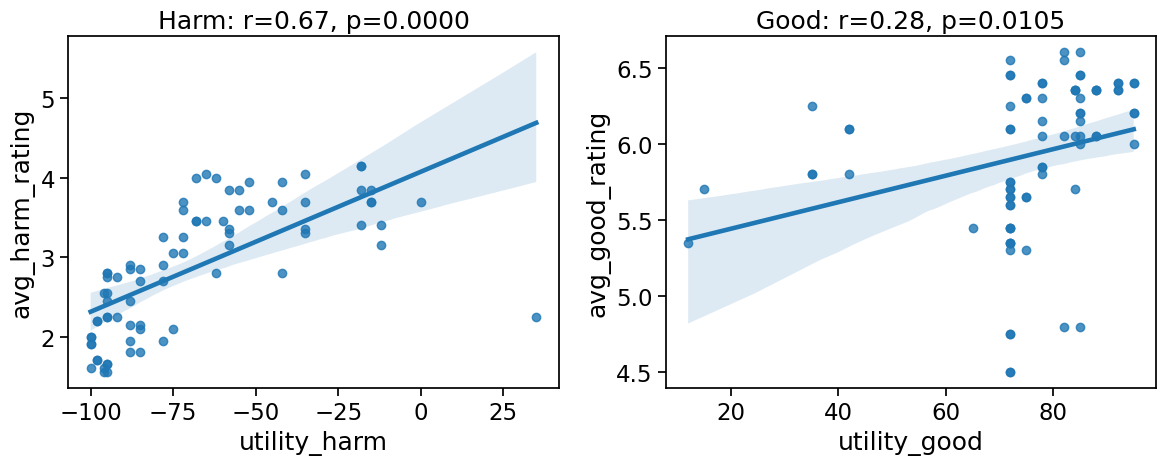

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=harm_df, x="utility_harm", y="avg_harm_rating", ax=axs[0])
axs[0].set_title(f"Harm: r={r_harm:.2f}, p={p_harm:.4f}")
sns.regplot(data=good_df, x="utility_good", y="avg_good_rating", ax=axs[1])
axs[1].set_title(f"Good: r={r_good:.2f}, p={p_good:.4f}")
plt.tight_layout()
plt.show()

### **RESULT:** Both harm rating and good rating are positively correlated with utility score!

#### This is good -- the humans gave the harm/good ratings on the same scale, where higher score = higher "goodness" of the event occurring in the target sentence. So as the `avg_harm_rating` OR `avg_good_rating` goes higher, i.e. people think the event in the target sentence is more "good" (or less bad), the utility score given by the annotator also increases.

#### We compare the human goodness rating to the most-positive utility event yielded by the annotator, and compare the human harm rating to the most-negative utility event. Because if the human is shown the target sentence with the positive event, they will think about the positive effects, and if they are shown the target sentence with the negative event, they will think about the negative effects.

### Does evitability / means-vs-sideeffect moderate this? Paired comparison of utility scores and human ratings

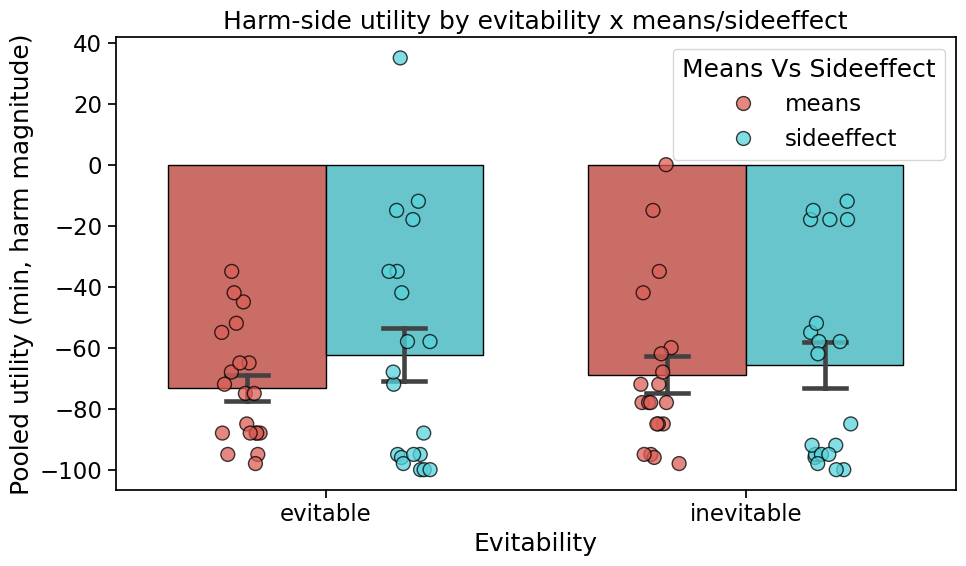

evitable: means vs sideeffect -- t(38.0): -1.118, p = 0.2705
inevitable: means vs sideeffect -- t(38.0): -0.328, p = 0.7448


In [ ]:
generic_analysis_utils.plot_bar_strip(harm_df, x="evitability", y="utility_harm", hue="means_vs_sideeffect", ylabel="Pooled utility (min, harm magnitude)", title="Harm-side utility by evitability x means/sideeffect")

for evit in harm_df["evitability"].unique():
    sub = harm_df[harm_df["evitability"] == evit]
    means_vals = sub[sub["means_vs_sideeffect"] == "means"]["utility_harm"]
    sideeffect_vals = sub[sub["means_vs_sideeffect"] == "sideeffect"]["utility_harm"]
    result = ttest_ind(means_vals, sideeffect_vals)
    print(f"{evit}: means vs sideeffect -- t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

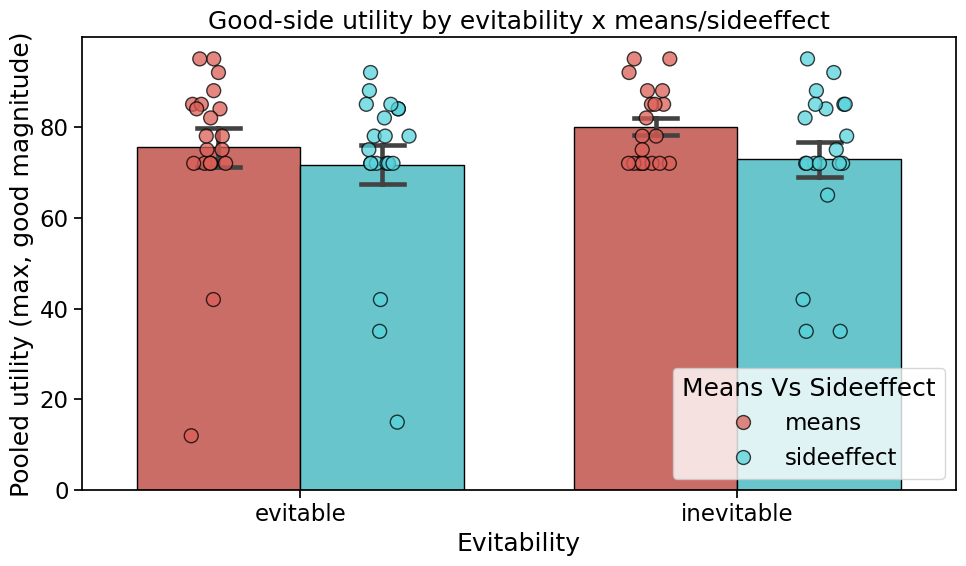

evitable: means vs sideeffect -- t(38.0): 0.639, p = 0.5267
inevitable: means vs sideeffect -- t(38.0): 1.678, p = 0.1016


In [ ]:
generic_analysis_utils.plot_bar_strip(good_df, x="evitability", y="utility_good", hue="means_vs_sideeffect", ylabel="Pooled utility (max, good magnitude)", title="Good-side utility by evitability x means/sideeffect")

for evit in good_df["evitability"].unique():
    sub = good_df[good_df["evitability"] == evit]
    means_vals = sub[sub["means_vs_sideeffect"] == "means"]["utility_good"]
    sideeffect_vals = sub[sub["means_vs_sideeffect"] == "sideeffect"]["utility_good"]
    result = ttest_ind(means_vals, sideeffect_vals)
    print(f"{evit}: means vs sideeffect -- t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

### **RESULT:** No -- looks like there is no significant difference in utility scores assigned to scenarios based on evitability or means-sideeffect categorization. One way to infer is that utility score assignment stays pretty consistent.